# Urban Validation — Global Metrics Aggregation

Reads per-city **vector** and **raster** summary parquets from `outputs/metrics/<city>/`,
aggregates to global-level metrics, and writes outputs to `outputs/global_metrics/`.

**Outputs (parquet + csv pairs)**
- `vector_all_cities_merged`  — all rows, all cities, vector pipeline
- `vector_global_summary_by_dataset` — one row per vector dataset
- `vector_detail_by_city_dataset` — full detail (city × dataset), vector
- `vector_best_dataset_per_city` — best vector dataset per city by F1
- `raster_all_cities_merged`  — all rows, all cities, raster pipeline
- `raster_global_summary_by_dataset` — one row per raster dataset
- `raster_detail_by_city_dataset` — full detail (city × dataset), raster
- `raster_best_dataset_per_city` — best raster dataset per city by F1

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [3]:
ROOT_DIR = Path("/content/drive/MyDrive/Gates Foundation/Building Dataset Validation/outputs/metrics")
OUT_DIR = Path("/content/drive/MyDrive/Gates Foundation/Building Dataset Validation/outputs/global_metrics")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Vector column config ──────────────────────────────────────────────────────
VECTOR_SUMMARY_FILE = "vector_city_summary_all_datasets.parquet"
VECTOR_SUMMARY_CSV  = "vector_city_summary_all_datasets.csv"   # fallback

VECTOR_WEIGHTED_MEAN_COLS = [
    "precision_city",
    "recall_city",
    "f1_city",
    "iou_mean_tp",
    "iou_median_tp",
    "iou_p25_tp",
    "iou_p75_tp",
    "boundary_f_meanpair_tp",
    "rel_area_error_mean_tp",
    "rel_area_error_median_tp",
    "signed_area_bias_tp",
]
VECTOR_SUM_COLS = [
    "n_sub_areas",
    "n_tiles",
    "n_ref_total",
    "n_cand_total",
    "tp_total",
    "fp_total",
    "fn_total",
]

# ── Raster column config ──────────────────────────────────────────────────────
RASTER_SUMMARY_FILE = "raster_city_summary_all_datasets.parquet"

# RASTER_WEIGHTED_MEAN_COLS = [
#     "precision_area",
#     "recall_area",
#     "f1_area",
#     "tile_f1_mean",
#     "tile_f1_median",
#     "tile_f1_p25",
#     "tile_f1_p75",
#     "rel_area_error_mean",
#     "rel_area_error_median",
#     "quantity_disagreement_mean",
#     "allocation_disagreement_mean",
# ]
# RASTER_SUM_COLS = [
#     "n_tiles",
#     "tp_m2",
#     "fp_m2",
#     "fn_m2",
#     "valid_area_total_m2",
#     "signed_area_bias_total_m2",
# ]


RASTER_SUM_COLS = [
    "valid_area_total_m2",
    "ref_area_total_m2",
    "pred_area_total_m2",
    "tp_total",
    "fp_total",
    "fn_total",
]

RASTER_WEIGHTED_MEAN_COLS = [
    "f1_area",
    "precision_area",
    "recall_area",
    "f1_tile_mean",
    "tile_f1_mean",
    "rel_area_error_mean",
    "rel_area_error_median",
    "signed_area_bias",
    "quantity_disagreement_mean",
    "allocation_disagreement_mean",
]

In [4]:
# ── Loader helpers ─────────────────────────────────────────────────────────────

def load_vector_cities(root: Path) -> pd.DataFrame:
    """Walk root/<CITY>/ and load vector city summary parquets (CSV fallback)."""
    frames, missing = [], []
    for city_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        pq_path  = city_dir / VECTOR_SUMMARY_FILE
        csv_path = city_dir / VECTOR_SUMMARY_CSV
        if pq_path.exists():
            df = pd.read_parquet(pq_path)
        elif csv_path.exists():
            df = pd.read_csv(csv_path)
        else:
            missing.append(city_dir.name)
            continue
        df["city"] = city_dir.name
        frames.append(df)
        print(f"  [V-OK]   {city_dir.name:35s}  ({len(df)} rows)")

    if missing:
        print(f"\n  [WARN] No vector summary for: {missing}")
    if not frames:
        raise RuntimeError("No vector city summaries found.")
    merged = pd.concat(frames, ignore_index=True)
    print(f"\n  → {len(frames)} cities | {len(merged)} rows")
    return merged


def load_raster_cities(root: Path) -> pd.DataFrame:
    """Walk root/<CITY>/ and load raster city summary parquets."""
    frames, missing = [], []
    for city_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        pq_path = city_dir / RASTER_SUMMARY_FILE
        if not pq_path.exists():
            missing.append(city_dir.name)
            continue
        df = pd.read_parquet(pq_path)
        # city column may already be present from the raster pipeline
        if "city" not in df.columns:
            df["city"] = city_dir.name
        frames.append(df)
        print(f"  [R-OK]   {city_dir.name:35s}  ({len(df)} rows)")

    if missing:
        print(f"\n  [WARN] No raster summary for: {missing}")
    if not frames:
        raise RuntimeError("No raster city summaries found.")
    merged = pd.concat(frames, ignore_index=True)
    print(f"\n  → {len(frames)} cities | {len(merged)} rows")
    return merged


# ── Aggregation helpers ────────────────────────────────────────────────────────

def weighted_mean(group: pd.DataFrame, cols: list, weight_col: str) -> pd.Series:
    w = group[weight_col].fillna(0)
    result = {}
    for col in cols:
        if col in group.columns and w.sum() > 0:
            result[col] = (group[col].fillna(0) * w).sum() / w.sum()
        else:
            result[col] = float("nan")
    return pd.Series(result)


def aggregate_vector_by_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """One row per vector dataset: counts summed, metrics weighted by n_ref_total."""
    rows = []
    for dataset, grp in df.groupby("dataset"):
        row = {"dataset": dataset, "n_cities": grp["city"].nunique()}
        for col in VECTOR_SUM_COLS:
            if col in grp.columns:
                row[col] = grp[col].sum()
        # Re-derive P/R/F1 from global TP+FP+FN
        tp, fp, fn = row.get("tp_total", 0), row.get("fp_total", 0), row.get("fn_total", 0)
        row["precision_global"] = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
        row["recall_global"]    = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        p, r = row["precision_global"], row["recall_global"]
        row["f1_global"] = (2 * p * r / (p + r)) if (p + r) > 0 else float("nan")
        # Weighted-mean quality metrics
        wm = weighted_mean(grp, VECTOR_WEIGHTED_MEAN_COLS, weight_col="n_ref_total")
        for col, val in wm.items():
            row[f"{col}_wavg"] = val
        rows.append(row)
    return pd.DataFrame(rows).set_index("dataset")


def aggregate_raster_by_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """One row per raster dataset: area counts summed, quality metrics weighted by valid_area_total_m2."""
    rows = []
    for dataset, grp in df.groupby("dataset"):
        row = {"dataset": dataset, "n_cities": grp["city"].nunique()}
        for col in RASTER_SUM_COLS:
            if col in grp.columns:
                row[col] = grp[col].sum()
        # Re-derive area P/R/F1 from global area sums
        tp_m2  = row.get("tp_m2", 0)
        fp_m2  = row.get("fp_m2", 0)
        fn_m2  = row.get("fn_m2", 0)
        row["precision_global"] = tp_m2 / (tp_m2 + fp_m2) if (tp_m2 + fp_m2) > 0 else float("nan")
        row["recall_global"]    = tp_m2 / (tp_m2 + fn_m2) if (tp_m2 + fn_m2) > 0 else float("nan")
        p, r = row["precision_global"], row["recall_global"]
        row["f1_global"] = (2 * p * r / (p + r)) if (p + r) > 0 else float("nan")
        # Weighted-mean quality metrics
        wm = weighted_mean(grp, RASTER_WEIGHTED_MEAN_COLS, weight_col="valid_area_total_m2")
        for col, val in wm.items():
            row[f"{col}_wavg"] = val
        rows.append(row)
    return pd.DataFrame(rows).set_index("dataset")

def aggregate_raster_by_dataset_grid(df: pd.DataFrame) -> pd.DataFrame:
    group_cols = ["dataset"]

    if "grid" in df.columns:
        group_cols.append("grid")
    if "resolution_m" in df.columns:
        group_cols.append("resolution_m")

    rows = []

    for keys, grp in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))
        row["n_cities"] = grp["city"].nunique()

        sum_cols = [
            "n_tiles",
            "valid_area_total_m2",
            "ref_area_total_m2",
            "pred_area_total_m2",
            "tp_total",
            "fp_total",
            "fn_total",
        ]

        for col in sum_cols:
            if col in grp.columns:
                row[col] = grp[col].sum()

        tp = row.get("tp_total", 0)
        fp = row.get("fp_total", 0)
        fn = row.get("fn_total", 0)

        row["precision_global"] = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        row["recall_global"] = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        p, r = row["precision_global"], row["recall_global"]
        row["f1_global"] = 2 * p * r / (p + r) if pd.notna(p) and pd.notna(r) and (p + r) > 0 else np.nan

        weighted_cols = [
            "f1_area",
            "precision_area",
            "recall_area",
            "f1_tile_mean",
            "f1_tile_median",
            "rel_area_error_mean",
            "rel_area_error_median",
            "signed_area_bias",
            "quantity_disagreement_mean",
            "allocation_disagreement_mean",
        ]

        wm = weighted_mean(grp, weighted_cols, weight_col="valid_area_total_m2")
        for col, val in wm.items():
            row[f"{col}_wavg"] = val

        rows.append(row)

    return pd.DataFrame(rows).set_index(group_cols).sort_index()

def best_vector_per_city(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.sort_values("f1_city", ascending=False)
          .groupby("city").first().reset_index()
          [["city", "dataset", "f1_city", "precision_city", "recall_city", "iou_mean_tp"]]
          .sort_values("f1_city", ascending=False).reset_index(drop=True)
    )


# def best_raster_per_city(df: pd.DataFrame) -> pd.DataFrame:
#     return (
#         df.sort_values("f1_area", ascending=False)
#           .groupby("city").first().reset_index()
#           [["city", "dataset", "f1_area", "precision_area", "recall_area", "tile_f1_mean"]]
#           .sort_values("f1_area", ascending=False).reset_index(drop=True)
#     )

def best_raster_per_city_grid(df: pd.DataFrame) -> pd.DataFrame:
    """
    Best raster dataset per city and grid/resolution.
    """
    group_cols = ["city"]

    if "grid" in df.columns:
        group_cols.append("grid")
    if "resolution_m" in df.columns:
        group_cols.append("resolution_m")

    f1_col = "f1_area"
    tile_f1_col = "tile_f1_mean" if "tile_f1_mean" in df.columns else "f1_tile_mean"

    keep_cols = [
        "city",
        "dataset",
        "f1_area",
        "precision_area",
        "recall_area",
        tile_f1_col,
    ]

    if "grid" in df.columns:
        keep_cols.insert(1, "grid")
    if "resolution_m" in df.columns:
        keep_cols.insert(2 if "grid" in df.columns else 1, "resolution_m")

    return (
        df.sort_values(f1_col, ascending=False)
          .groupby(group_cols, dropna=False)
          .first()
          .reset_index()
          [keep_cols]
          .sort_values(group_cols + [f1_col], ascending=[True] * len(group_cols) + [False])
          .reset_index(drop=True)
    )


def save(df: pd.DataFrame, stem: str, index: bool = True) -> None:
    pq_path  = OUT_DIR / f"{stem}.parquet"
    csv_path = OUT_DIR / f"{stem}.csv"
    df.to_parquet(pq_path, index=index)
    df.to_csv(csv_path, index=index)
    print(f"  Saved → {pq_path.name}  |  {csv_path.name}")

## 1. Load and aggregate vector data

In [5]:
print(f"Scanning: {ROOT_DIR.resolve()}\n")

df_vec = load_vector_cities(ROOT_DIR)

save(df_vec,                                  "vector_all_cities_merged",       index=False)
save(aggregate_vector_by_dataset(df_vec),     "vector_global_summary_by_dataset")
save(df_vec.set_index(["city", "dataset"]).sort_index(),
                                              "vector_detail_by_city_dataset")
save(best_vector_per_city(df_vec),            "vector_best_dataset_per_city",   index=False)

Scanning: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics

  [V-OK]   afg-ayabak                           (3 rows)
  [V-OK]   afg-bamyan                           (3 rows)
  [V-OK]   afg-bazarak                          (3 rows)
  [V-OK]   afg-charikar                         (3 rows)
  [V-OK]   afg-east-kabul                       (3 rows)
  [V-OK]   afg-ferozkoh                         (3 rows)
  [V-OK]   afg-gardez                           (3 rows)
  [V-OK]   afg-herat                            (3 rows)
  [V-OK]   afg-jalalaba                         (3 rows)
  [V-OK]   afg-mahmud-e-raqi                    (3 rows)
  [V-OK]   afg-poruns                           (3 rows)
  [V-OK]   afg-qala-e-naw                       (3 rows)
  [V-OK]   afg-zaranj                           (3 rows)
  [V-OK]   ant-curacao                          (3 rows)
  [V-OK]   bgd-rohingya                         (3 rows)


## 2. Load and aggregate raster data

In [6]:
df_ras = load_raster_cities(ROOT_DIR)

df_ras = load_raster_cities(ROOT_DIR)

save(df_ras, "raster_all_cities_merged", index=False)

save(
    aggregate_raster_by_dataset_grid(df_ras),
    "raster_global_summary_by_dataset_grid"
)

detail_index = ["city", "dataset"]
if "grid" in df_ras.columns:
    detail_index.append("grid")
if "resolution_m" in df_ras.columns:
    detail_index.append("resolution_m")

save(
    df_ras.set_index(detail_index).sort_index(),
    "raster_detail_by_city_dataset_grid"
)

save(
    best_raster_per_city_grid(df_ras),
    "raster_best_dataset_per_city_grid",
    index=False
)


# save(df_ras,                                  "raster_all_cities_merged",       index=False)
# save(aggregate_raster_by_dataset(df_ras),     "raster_global_summary_by_dataset")
# save(df_ras.set_index(["city", "dataset"]).sort_index(),
#                                               "raster_detail_by_city_dataset")
# save(best_raster_per_city(df_ras),            "raster_best_dataset_per_city",   index=False)

  [R-OK]   afg-ayabak                           (12 rows)
  [R-OK]   afg-bamyan                           (12 rows)
  [R-OK]   afg-bazarak                          (12 rows)
  [R-OK]   afg-charikar                         (12 rows)
  [R-OK]   afg-east-kabul                       (12 rows)
  [R-OK]   afg-ferozkoh                         (9 rows)
  [R-OK]   afg-gardez                           (12 rows)
  [R-OK]   afg-herat                            (9 rows)
  [R-OK]   afg-jalalaba                         (12 rows)
  [R-OK]   afg-mahmud-e-raqi                    (12 rows)
  [R-OK]   afg-mazar-e-sharif                   (9 rows)
  [R-OK]   afg-poruns                           (12 rows)
  [R-OK]   afg-qala-e-naw                       (9 rows)
  [R-OK]   afg-zaranj                           (9 rows)
  [R-OK]   ant-curacao                          (12 rows)
  [R-OK]   bgd-rohingya                         (12 rows)
  [R-OK]   blz-burrell-boom                     (12 rows)
  [R-OK]   bra-nova

## 3. Display global summaries

In [13]:
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

df_vec_global = aggregate_vector_by_dataset(df_vec)
print("\n VECTOR — GLOBAL SUMMARY BY DATASET")
display(df_vec_global[[
    "n_cities", "n_ref_total", "tp_total", "fp_total", "fn_total",
    "precision_global", "recall_global", "f1_global",
    "iou_mean_tp_wavg", "iou_median_tp_wavg",
]])


 VECTOR — GLOBAL SUMMARY BY DATASET


,n_cities,n_ref_total,tp_total,fp_total,fn_total,precision_global,recall_global,f1_global,iou_mean_tp_wavg,iou_median_tp_wavg
dataset,,,,,,,,,,
gba,83,2534366,1770541,1133141,763825,0.6098,0.6986,0.6512,0.8318,0.8282
globfp,78,2481886,937543,1141889,1544343,0.4509,0.3778,0.4111,0.6462,0.6438
overture,83,2534366,2296703,684634,237663,0.7704,0.9062,0.8328,0.9690,0.9828


In [14]:
# print("\n RASTER — GLOBAL SUMMARY BY DATASET")
# display(df_ras_global[[
#     "n_cities", "n_tiles", "tp_m2", "fp_m2", "fn_m2",
#     "precision_global", "recall_global", "f1_global",
#     "tile_f1_mean_wavg", "tile_f1_median_wavg", "rel_area_error_mean_wavg",
# ]])
df_ras_global = aggregate_raster_by_dataset_grid(df_ras)

print("\n RASTER — GLOBAL SUMMARY BY DATASET × GRID")

display_cols = [
    "n_cities",
    "n_tiles",
    "valid_area_total_m2",
    "ref_area_total_m2",
    "pred_area_total_m2",
    "tp_total",
    "fp_total",
    "fn_total",
    "precision_global",
    "recall_global",
    "f1_global",
    "f1_area_wavg",
    "f1_tile_mean_wavg",
    "tile_f1_mean_wavg",
    "rel_area_error_mean_wavg",
    "signed_area_bias_wavg",
    "quantity_disagreement_mean_wavg",
    "allocation_disagreement_mean_wavg",
]

# display(
#     df_ras_global[
#         [c for c in display_cols if c in df_ras_global.columns]
#     ]
# )

display(
    df_ras_global.reset_index()[
        [c for c in ["dataset", "grid", "resolution_m"] + display_cols
         if c in df_ras_global.reset_index().columns]
    ]
)


 RASTER — GLOBAL SUMMARY BY DATASET × GRID


,dataset,grid,resolution_m,n_cities,n_tiles,valid_area_total_m2,ref_area_total_m2,pred_area_total_m2,tp_total,fp_total,fn_total,precision_global,recall_global,f1_global,f1_area_wavg,f1_tile_mean_wavg,rel_area_error_mean_wavg,signed_area_bias_wavg,quantity_disagreement_mean_wavg,allocation_disagreement_mean_wavg
0,ghsl_built_s_2020,100m,100.0000,82,11369,1358640000.0000,170597343.7500,192504843.5874,24292.0000,16156.0000,9810.0000,0.6006,0.7123,0.6517,0.5565,0.5510,1.3519,0.1384,0.0972,0.0269
1,ghsl_built_s_2020,10m,10.0000,82,11369,1357948100.0000,177472233.7188,1278085461.8688,3022050.0000,10222171.0000,9239.0000,0.2282,0.9970,0.3714,0.3549,0.2628,77.9788,8.8941,0.7854,0.0028
2,ghsl_built_s_2020,30m,30.0000,82,11369,1358484300.0000,176624490.2500,913554207.4468,400595.0000,830600.0000,14219.0000,0.3254,0.9657,0.4867,0.4454,0.3478,21.0506,5.1667,0.4864,0.0213
3,ghsl_built_s_2020,NaN,NaN,1,841,732084910.5930,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,0.5628,0.0000,1.7792,0.0000,0.0063,0.0013
4,obt_2023,100m,100.0000,62,9937,4475850000.0000,179575625.0000,137665251.2872,14495.0000,9649.0000,13946.0000,0.6004,0.5097,0.5513,0.3864,0.4316,-0.0290,-0.1770,0.0383,0.0111
5,obt_2023,10m,10.0000,62,9937,4476353500.0000,189008512.5000,137368562.8130,1698095.0000,887878.0000,1452117.0000,0.6567,0.5390,0.5921,0.5306,0.4779,0.3190,-0.2094,0.0298,0.0188
6,obt_2023,30m,30.0000,62,9937,4476115800.0000,187234481.2500,137806788.7053,213793.0000,90957.0000,175740.0000,0.7015,0.5488,0.6159,0.5127,0.4594,0.2403,-0.2039,0.0353,0.0148
7,obt_2023,NaN,NaN,1,841,749632268.3102,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,0.6369,0.0000,0.8083,0.0000,0.0044,0.0039
8,tempo_2023q4,100m,100.0000,82,11369,7980410000.0000,260159335.9375,308171540.7281,36637.0000,15529.0000,7473.0000,0.7023,0.8306,0.7611,0.6367,0.6386,0.7505,0.1673,0.0189,0.0087
9,tempo_2023q4,10m,10.0000,82,11369,7978351100.0000,268704608.9844,308188176.2541,2516540.0000,2796266.0000,2132642.0000,0.4737,0.5413,0.5052,0.3526,0.3062,0.9164,0.1324,0.0380,0.0191


## 4. Vector — best dataset per city (F1)

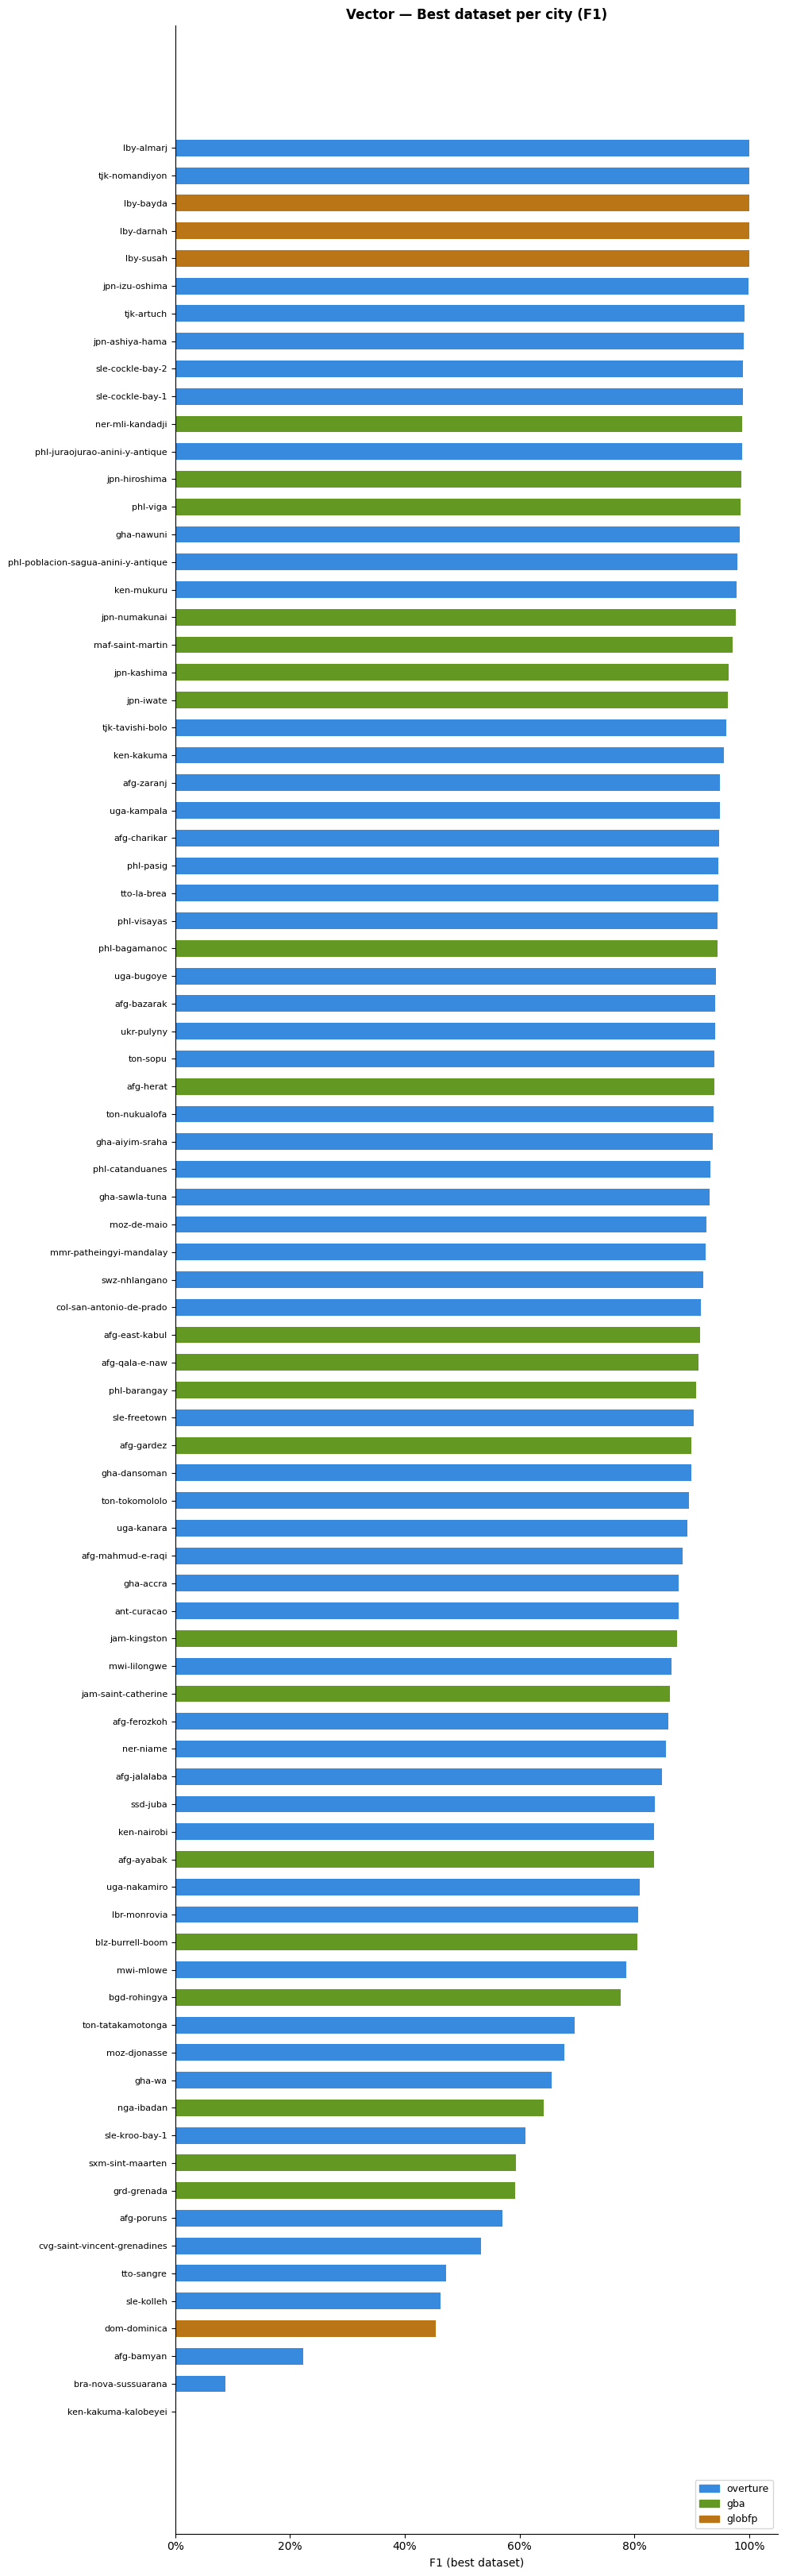

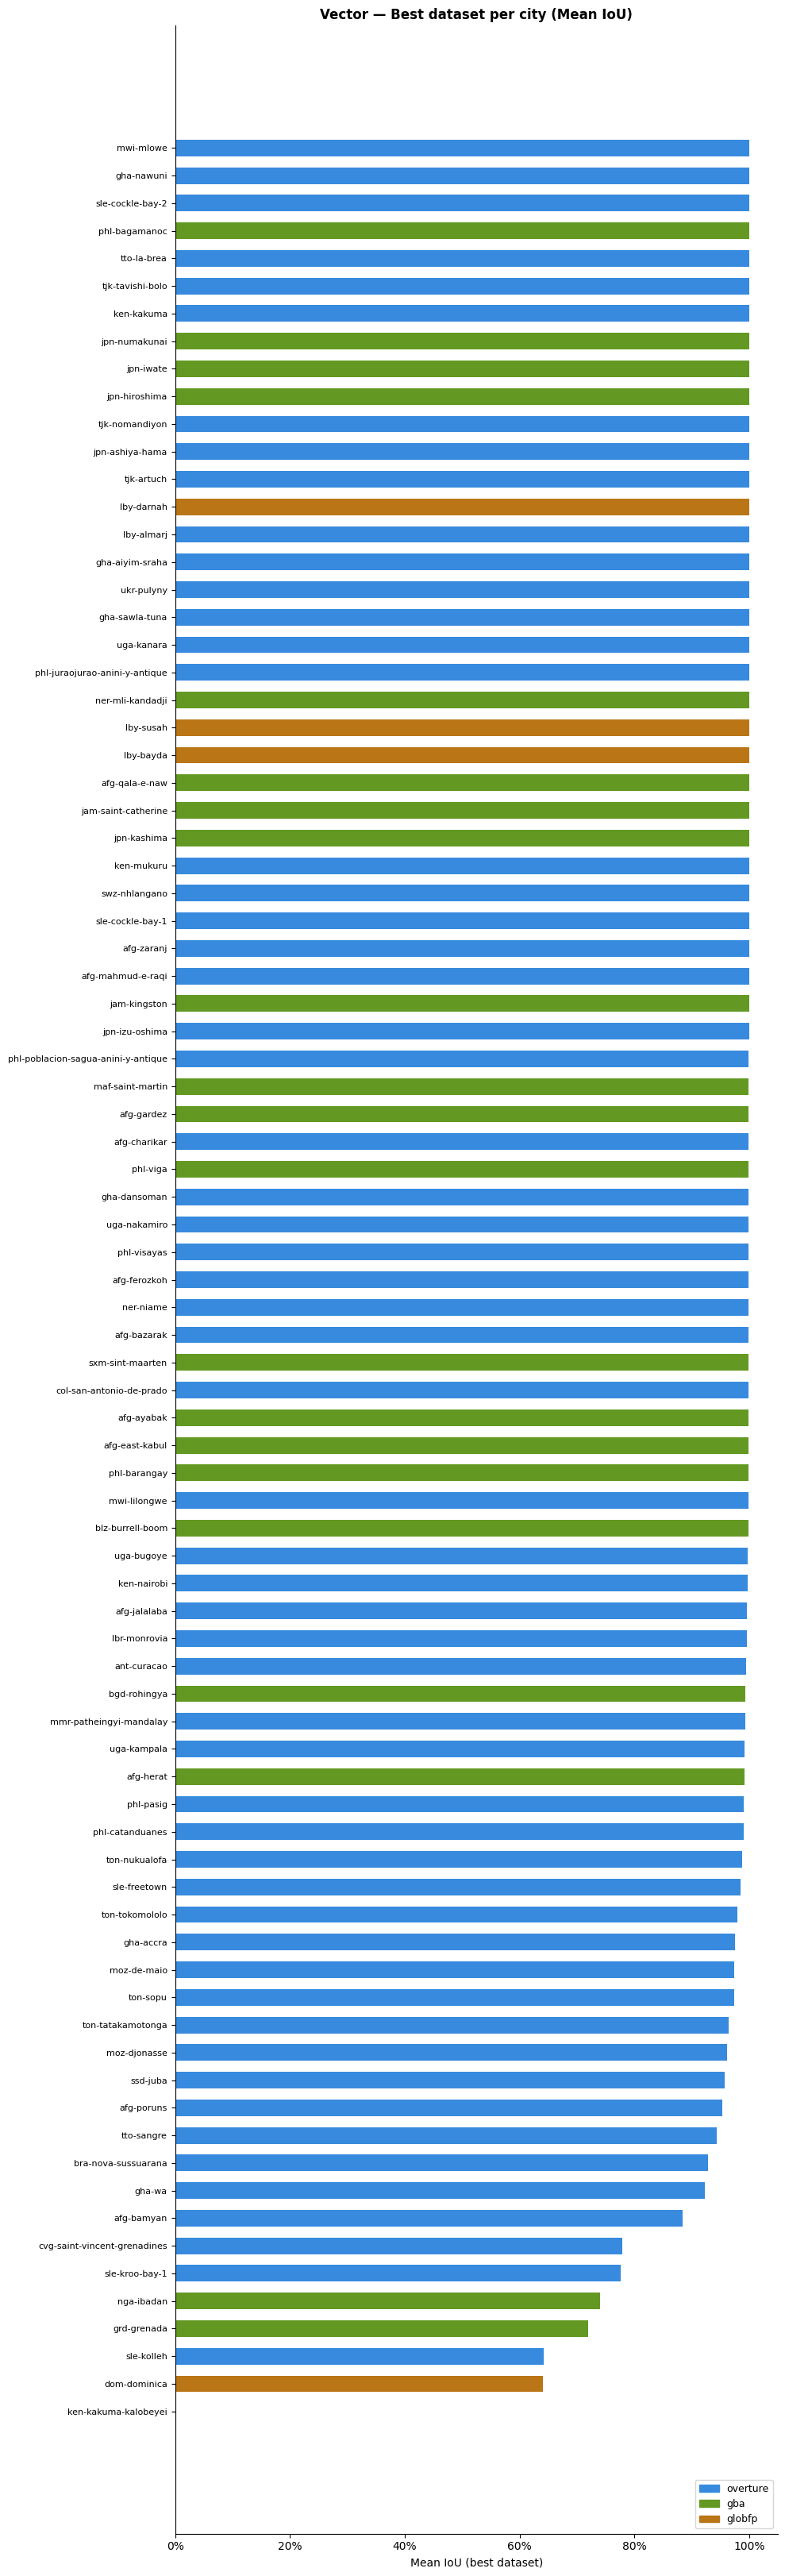

In [15]:
VEC_PALETTE = {"overture": "#378ADD", "gba": "#639922", "globfp": "#BA7517"}

def barh_best(df_best: pd.DataFrame, metric: str, palette: dict,
              xlabel: str, title: str) -> None:
    df_plot = df_best.sort_values(metric, ascending=True)
    colors  = df_plot["dataset"].map(palette).fillna("#999999")
    fig, ax = plt.subplots(figsize=(10, len(df_plot) * 0.38 + 1))
    ax.barh(df_plot["city"], df_plot[metric], color=colors, height=0.6)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    legend = [mpatches.Patch(color=c, label=ds) for ds, c in palette.items()
              if ds in df_plot["dataset"].values]
    ax.legend(handles=legend, loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.show()

df_vec_best = best_vector_per_city(df_vec)

barh_best(df_vec_best, "f1_city",   VEC_PALETTE, "F1 (best dataset)",         "Vector — Best dataset per city (F1)")
barh_best(df_vec_best, "iou_mean_tp", VEC_PALETTE, "Mean IoU (best dataset)", "Vector — Best dataset per city (Mean IoU)")

## 5. Vector — all datasets F1 comparison (grouped bar)

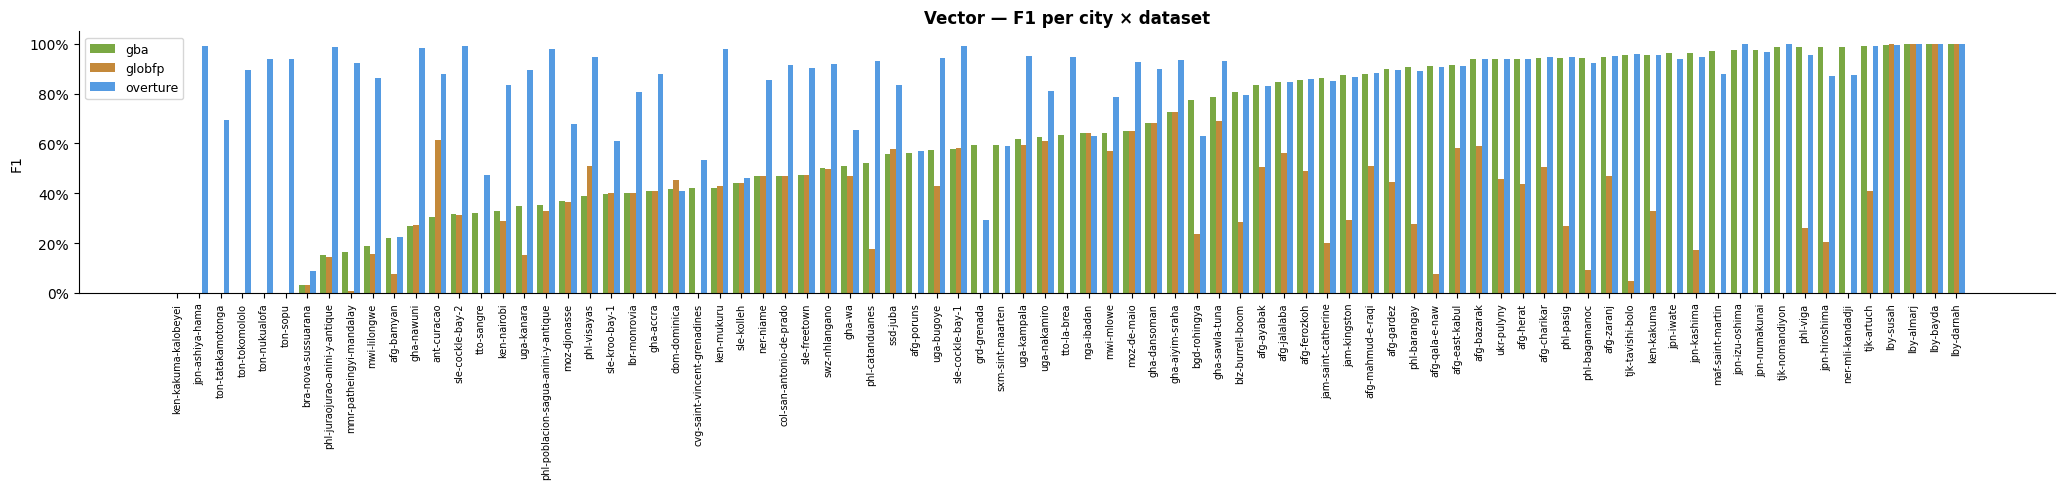

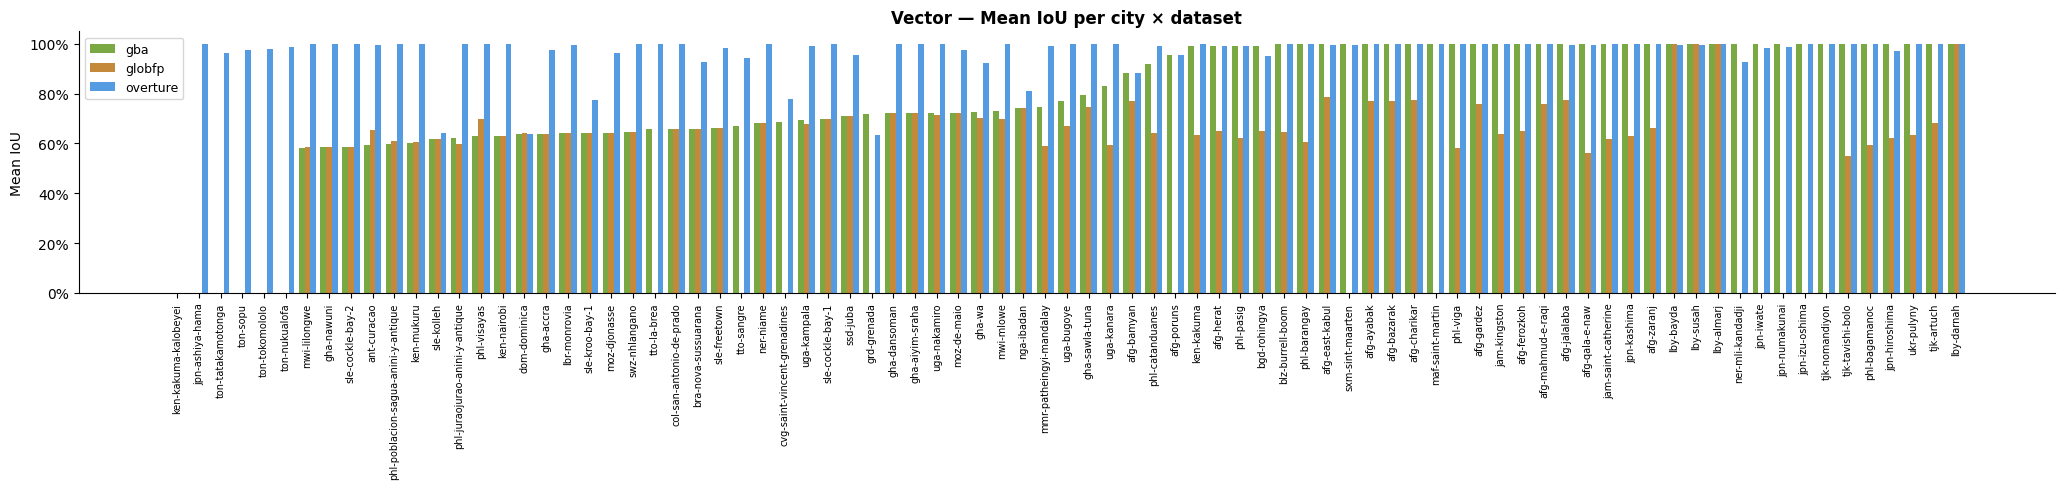

In [16]:
def grouped_bar_all(df: pd.DataFrame, metric: str, palette: dict,
                    ylabel: str, title: str) -> None:
    pivot = df.pivot(index="city", columns="dataset", values=metric).sort_values(
        df["dataset"].iloc[0] if df["dataset"].nunique() > 0 else metric, ascending=True
    )
    pivot = pivot.sort_values(list(pivot.columns), ascending=True)
    datasets = pivot.columns.tolist()
    cities   = pivot.index.tolist()
    n_ds, n_c = len(datasets), len(cities)
    x   = np.arange(n_c)
    w   = 0.8 / n_ds
    fig, ax = plt.subplots(figsize=(max(14, n_c * 0.25), 5))
    for i, ds in enumerate(datasets):
        color = palette.get(ds, f"C{i}")
        ax.bar(x + i * w - 0.4 + w / 2, pivot[ds].fillna(0), width=w,
               label=ds, color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=90, fontsize=7)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(title, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

grouped_bar_all(df_vec, "f1_city",    VEC_PALETTE, "F1",       "Vector — F1 per city × dataset")
grouped_bar_all(df_vec, "iou_mean_tp", VEC_PALETTE, "Mean IoU", "Vector — Mean IoU per city × dataset")

## 6. Raster — best dataset per city (area F1)

In [18]:
# RAS_PALETTE = {"obt_2023": "#E07B39", "tempo_2023q4": "#5B8DB8", "ghsl_built_s_2020": "#7DB87D", "wsf_tracker": "#B85C9E"}

# # Normalise dataset names (underscore vs hyphen variations)
# df_ras["dataset"] = df_ras["dataset"].str.replace("-", "_")

# # df_ras_best = best_raster_per_city(df_ras)
# df_ras_best = best_raster_per_city_grid(df_ras)

# barh_best(df_ras_best, "f1_area",     RAS_PALETTE, "Area F1 (best dataset)",      "Raster — Best dataset per city (Area F1)")
# barh_best(df_ras_best, "tile_f1_mean", RAS_PALETTE, "Mean tile F1 (best dataset)", "Raster — Best dataset per city (Mean Tile F1)")

def barh_best_grid(
    df_best: pd.DataFrame,
    metric: str,
    palette: dict,
    xlabel: str,
    title: str,
    grid=None,
    resolution_m=None,
) -> None:
    df_plot = df_best.copy()

    if grid is not None and "grid" in df_plot.columns:
        df_plot = df_plot[df_plot["grid"].astype(str) == str(grid)]

    if resolution_m is not None and "resolution_m" in df_plot.columns:
        df_plot = df_plot[df_plot["resolution_m"].astype(float) == float(resolution_m)]

    if df_plot.empty:
        print(f"No rows to plot for grid={grid}, resolution_m={resolution_m}")
        return

    if metric not in df_plot.columns:
        raise ValueError(f"{metric!r} not found. Available columns: {list(df_plot.columns)}")

    label = "city"
    if "grid" in df_plot.columns:
        df_plot["city_grid"] = df_plot["city"].astype(str) + " (" + df_plot["grid"].astype(str) + ")"
        label = "city_grid"

    df_plot = df_plot.sort_values(metric, ascending=True)
    colors = df_plot["dataset"].map(palette).fillna("#999999")

    fig, ax = plt.subplots(figsize=(10, len(df_plot) * 0.38 + 1))
    ax.barh(df_plot[label], df_plot[metric], color=colors, height=0.6)

    ax.set_xlim(0, 1.05)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

    suffix = ""
    if grid is not None:
        suffix = f" — {grid}"
    elif resolution_m is not None:
        suffix = f" — {resolution_m:g}m"

    ax.set_title(title + suffix, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    legend = [
        mpatches.Patch(color=c, label=ds)
        for ds, c in palette.items()
        if ds in df_plot["dataset"].values
    ]
    ax.legend(handles=legend, loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.show()

    

In [19]:
RAS_PALETTE = {
    "obt_2023": "#E07B39",
    "tempo_2023q4": "#5B8DB8",
    "ghsl_built_s_2020": "#7DB87D",
    "wsf_tracker": "#B85C9E",
}

df_ras["dataset"] = df_ras["dataset"].str.replace("-", "_", regex=False)

df_ras_best = best_raster_per_city_grid(df_ras)

# normalize tile metric name
if "tile_f1_mean" not in df_ras_best.columns and "f1_tile_mean" in df_ras_best.columns:
    df_ras_best["tile_f1_mean"] = df_ras_best["f1_tile_mean"]

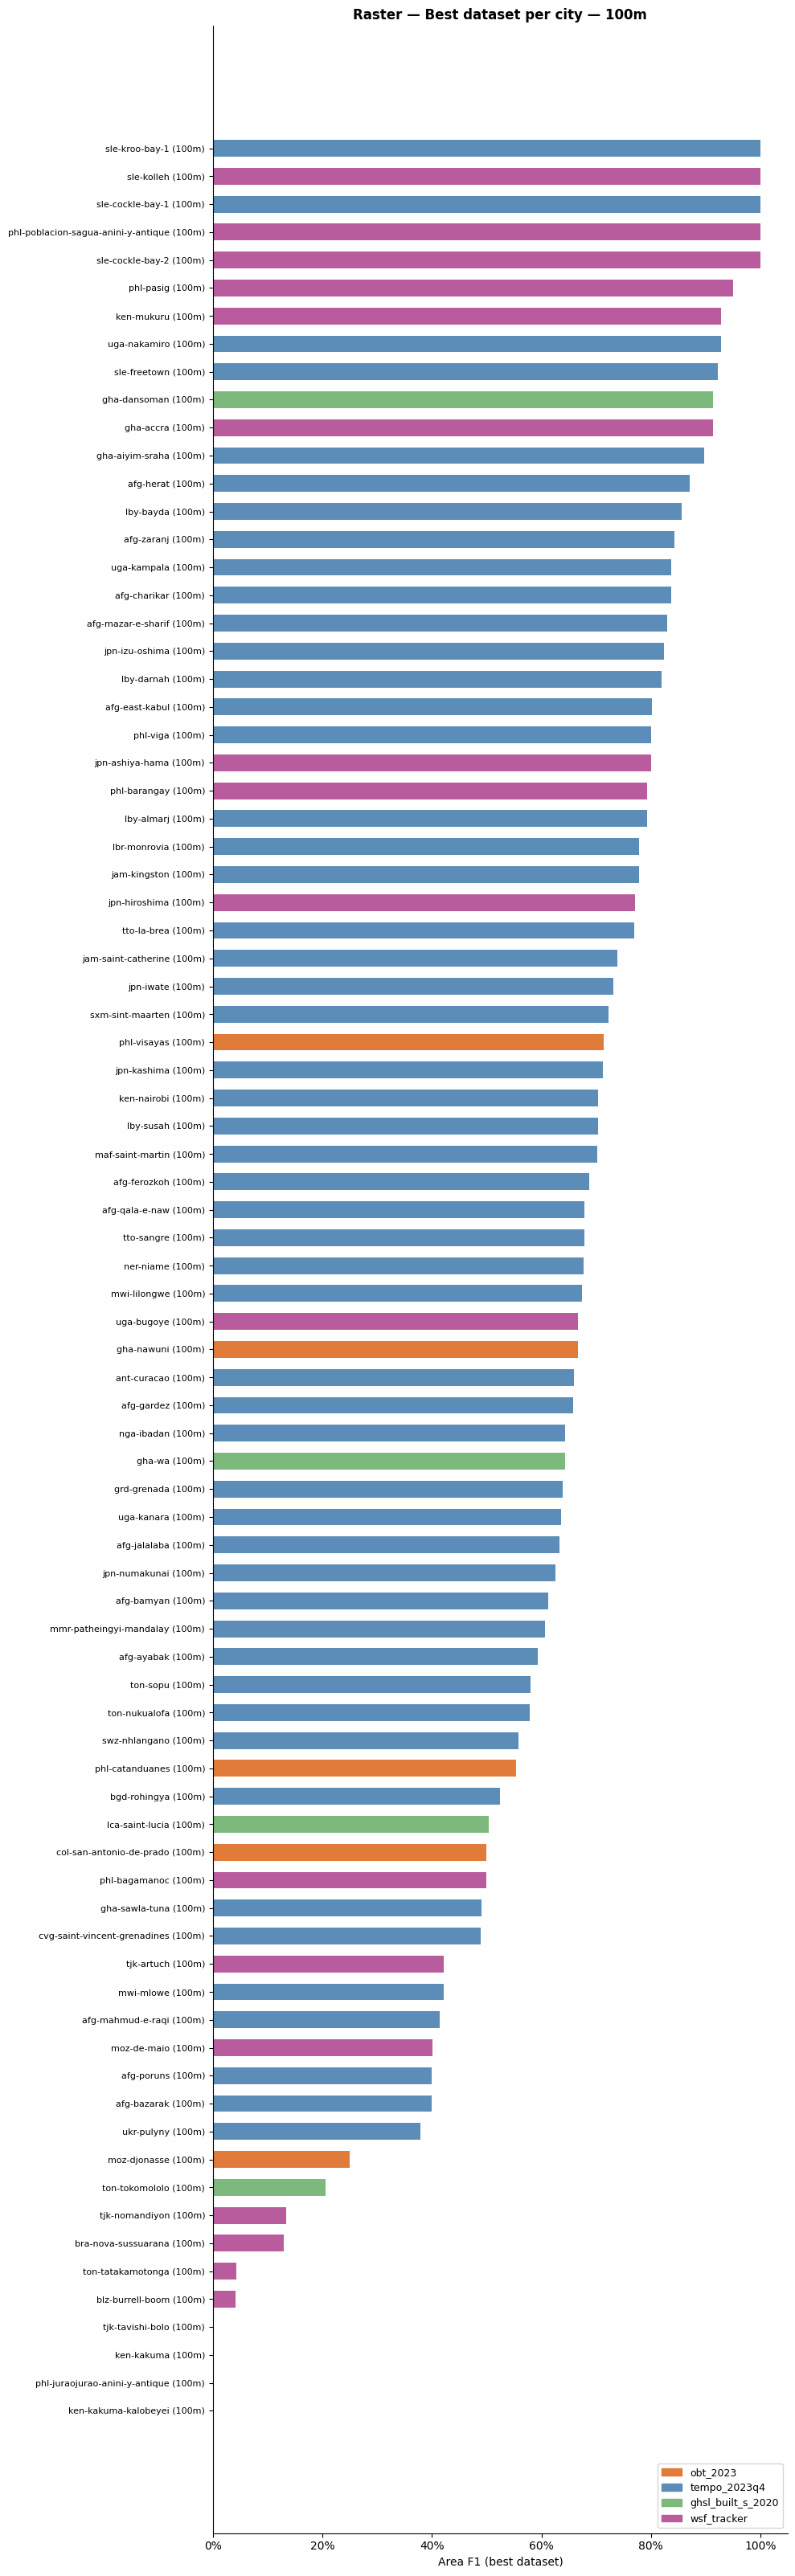

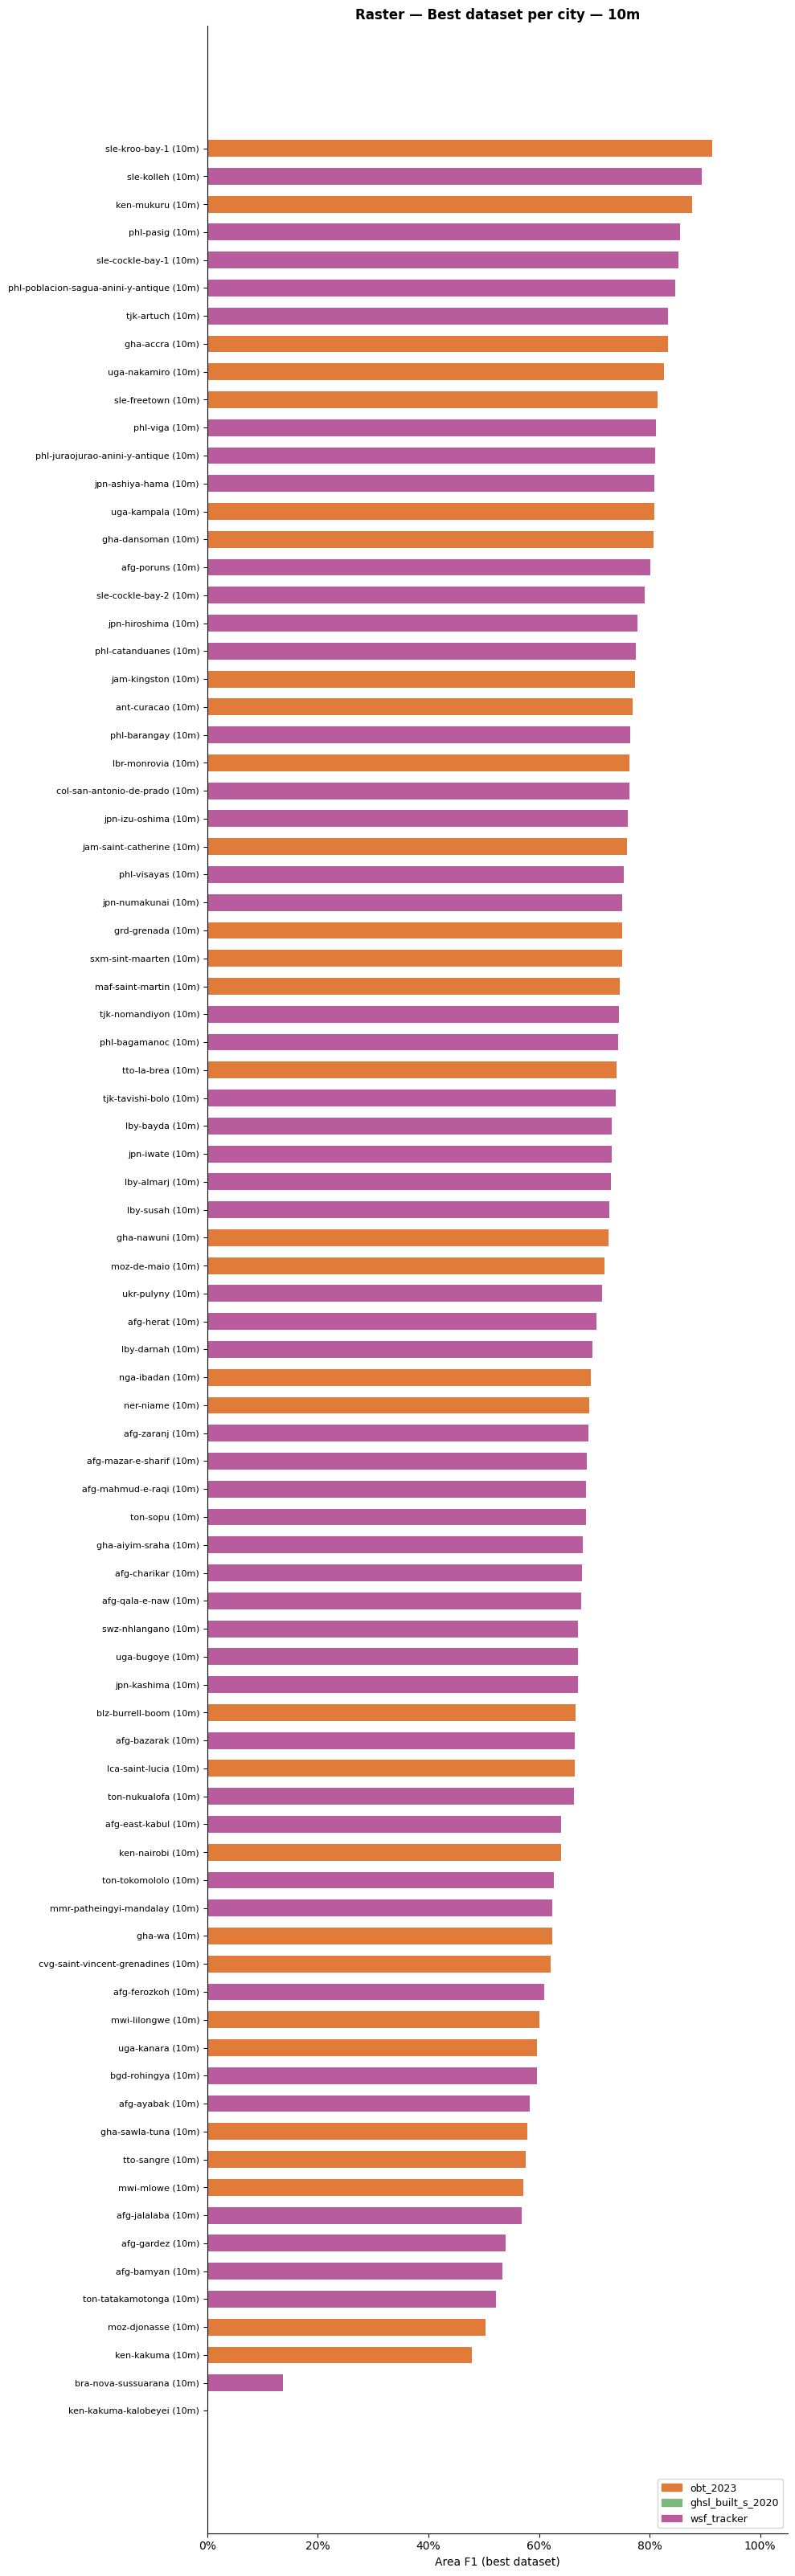

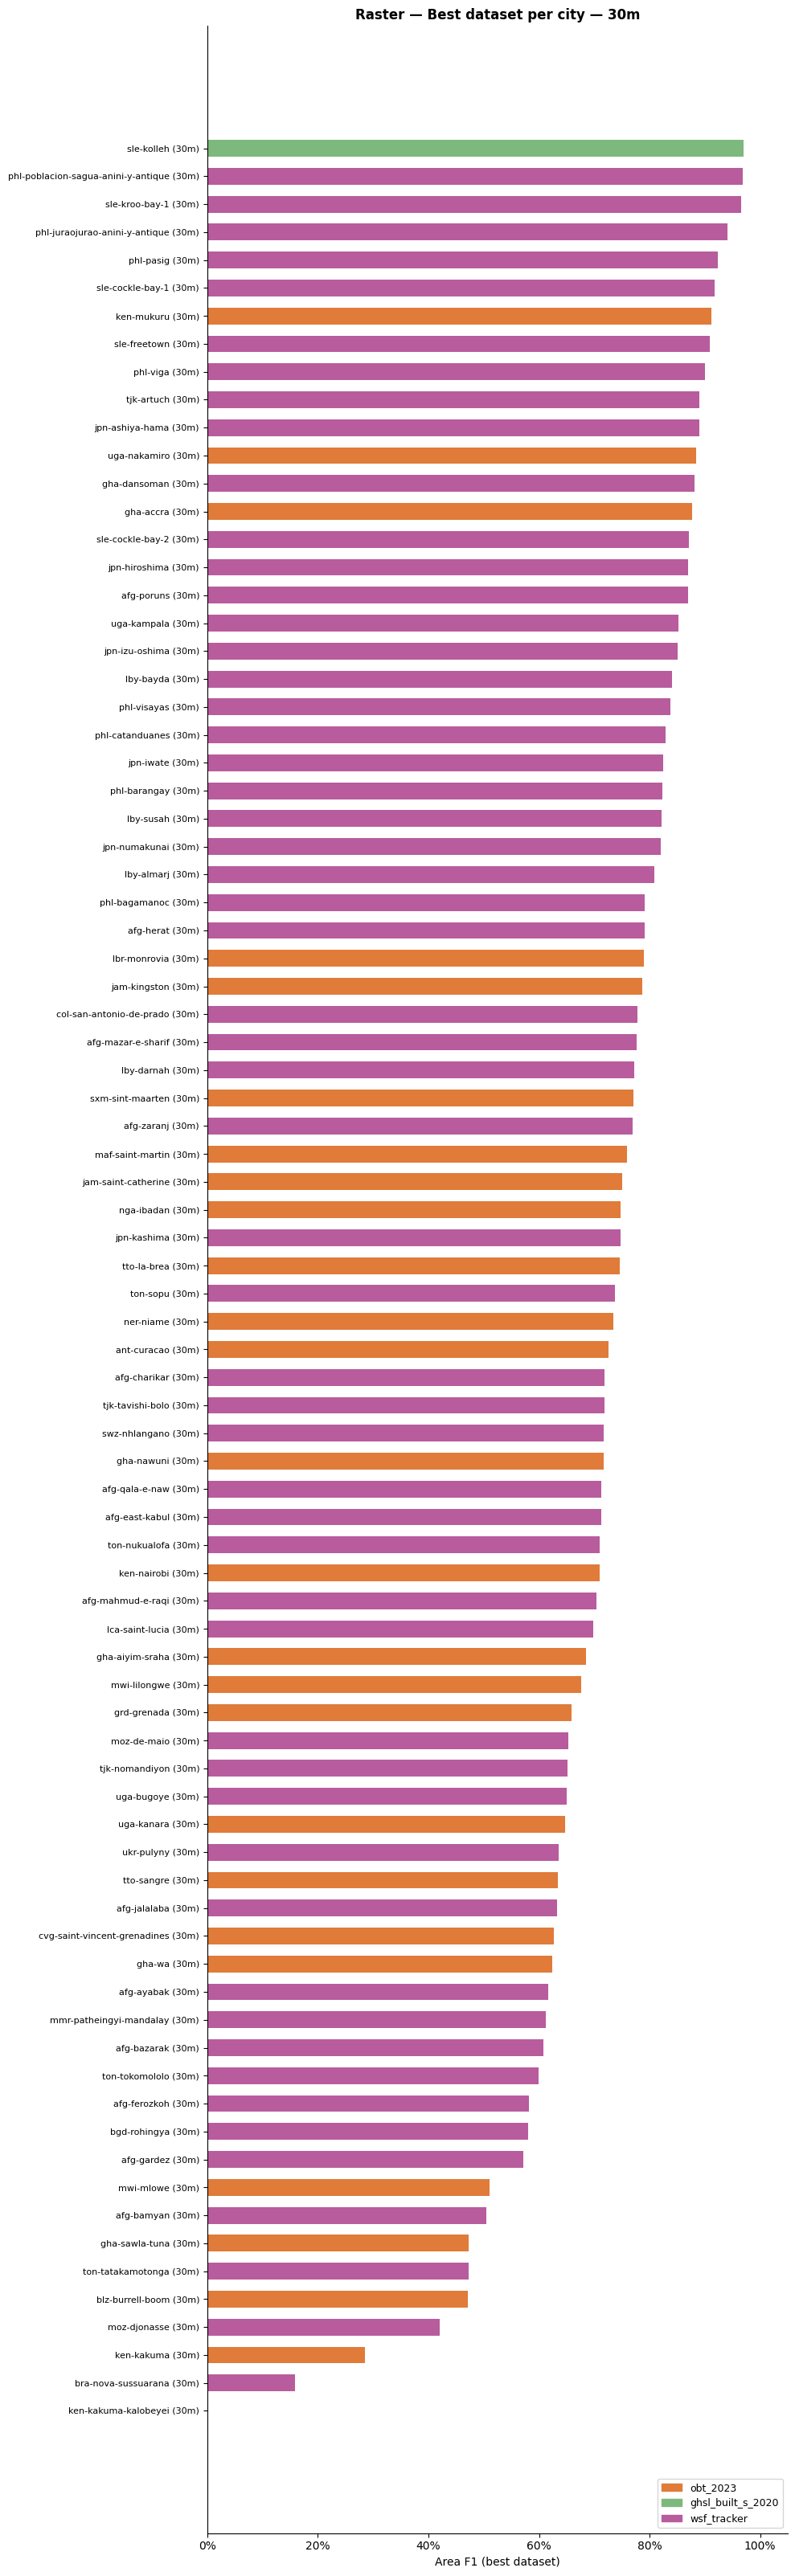

In [21]:
for grid in sorted(df_ras_best["grid"].dropna().unique()):
    barh_best_grid(
        df_ras_best,
        "f1_area",
        RAS_PALETTE,
        "Area F1 (best dataset)",
        "Raster — Best dataset per city",
        grid=grid,
    )

    # barh_best_grid(
    #     df_ras_best,
    #     "tile_f1_mean",
    #     RAS_PALETTE,
    #     "Mean tile F1 (best dataset)",
    #     "Raster — Best dataset per city",
    #     grid=grid,
    # )

## 7. Raster — all datasets area-F1 comparison

In [22]:
grouped_bar_all(df_ras, "f1_area",     RAS_PALETTE, "Area F1",      "Raster — Area F1 per city × dataset")
grouped_bar_all(df_ras, "tile_f1_mean", RAS_PALETTE, "Mean Tile F1", "Raster — Mean Tile F1 per city × dataset")

ValueError: Index contains duplicate entries, cannot reshape

## 8. Global summary bar chart — vector vs raster side-by-side

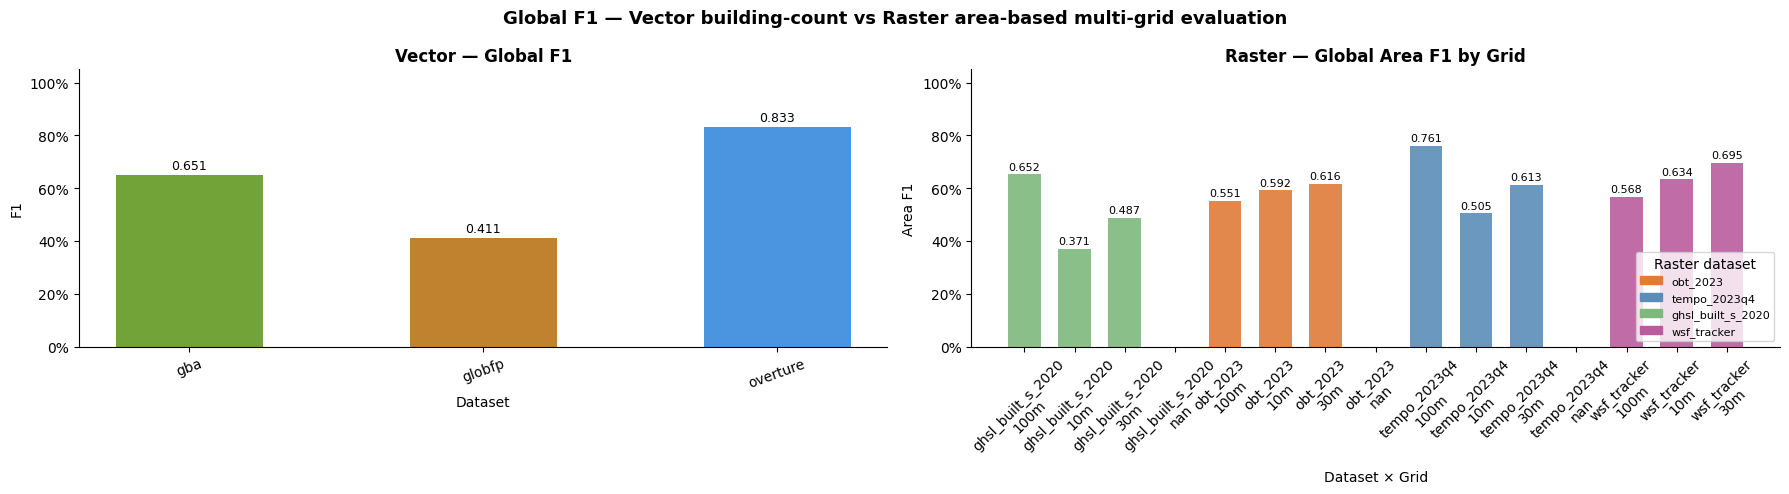

In [24]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# for ax, (df_g, palette, title, metric) in zip(
#     axes,
#     [
#         (df_vec_global.reset_index(), VEC_PALETTE, "Vector — Global F1",      "f1_global"),
#         (df_ras_global.reset_index(), RAS_PALETTE, "Raster — Global Area F1", "f1_global"),
#     ],
# ):
#     colors = df_g["dataset"].map(palette).fillna("#999999")
#     ax.bar(df_g["dataset"], df_g[metric], color=colors, width=0.5, alpha=0.9)
#     ax.set_ylim(0, 1.05)
#     ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
#     ax.set_title(title, fontweight="bold")
#     ax.set_xlabel("Dataset")
#     ax.set_ylabel("F1")
#     ax.tick_params(axis="x", rotation=20)
#     ax.spines[["top", "right"]].set_visible(False)
#     for bar, val in zip(ax.patches, df_g[metric]):
#         if np.isfinite(val):
#             ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
#                     f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# fig.suptitle("Global F1 — Vector (building-count) vs Raster (area-based)", fontsize=13, fontweight="bold")
# plt.tight_layout()
# plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# -------------------------
# Vector panel
# -------------------------
df_v = df_vec_global.reset_index().copy()
colors = df_v["dataset"].map(VEC_PALETTE).fillna("#999999")

axes[0].bar(df_v["dataset"], df_v["f1_global"], color=colors, width=0.5, alpha=0.9)
axes[0].set_title("Vector — Global F1", fontweight="bold")
axes[0].set_xlabel("Dataset")
axes[0].set_ylabel("F1")
axes[0].tick_params(axis="x", rotation=20)

for bar, val in zip(axes[0].patches, df_v["f1_global"]):
    if np.isfinite(val):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

# -------------------------
# Raster panel: dataset × grid
# -------------------------
df_r = df_ras_global.reset_index().copy()

if "grid" not in df_r.columns:
    df_r["grid"] = df_r["resolution_m"].astype(str) + "m"

df_r["dataset_grid"] = df_r["dataset"].astype(str) + "\n" + df_r["grid"].astype(str)

colors = df_r["dataset"].map(RAS_PALETTE).fillna("#999999")

axes[1].bar(df_r["dataset_grid"], df_r["f1_global"], color=colors, width=0.65, alpha=0.9)
axes[1].set_title("Raster — Global Area F1 by Grid", fontweight="bold")
axes[1].set_xlabel("Dataset × Grid")
axes[1].set_ylabel("Area F1")
axes[1].tick_params(axis="x", rotation=45)

for bar, val in zip(axes[1].patches, df_r["f1_global"]):
    if np.isfinite(val):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

# Shared formatting
for ax in axes:
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.spines[["top", "right"]].set_visible(False)

# Raster legend by dataset
legend = [
    mpatches.Patch(color=c, label=ds)
    for ds, c in RAS_PALETTE.items()
    if ds in df_r["dataset"].values
]
axes[1].legend(handles=legend, title="Raster dataset", fontsize=8, loc="lower right")

fig.suptitle(
    "Global F1 — Vector building-count vs Raster area-based multi-grid evaluation",
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

## 9. Relative area error — raster global (tile-level, weighted avg)

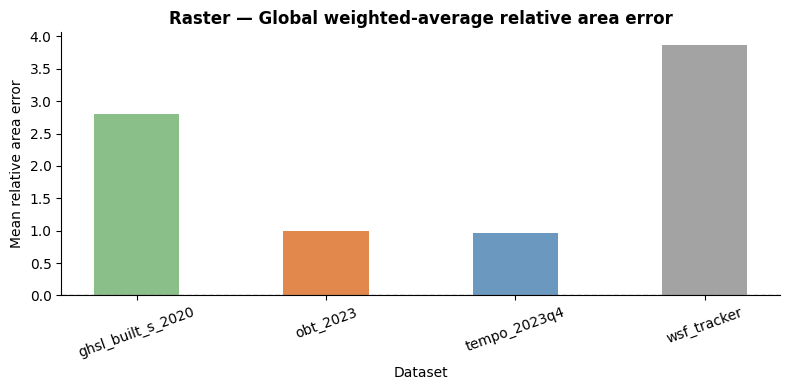

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
df_err = df_ras_global.reset_index()[["dataset", "rel_area_error_mean_wavg"]].dropna()
colors = df_err["dataset"].map(RAS_PALETTE).fillna("#999999")
ax.bar(df_err["dataset"], df_err["rel_area_error_mean_wavg"], color=colors, width=0.45, alpha=0.9)
ax.axhline(0, linestyle="--", linewidth=1, color="grey")
ax.set_title("Raster — Global weighted-average relative area error", fontweight="bold")
ax.set_xlabel("Dataset")
ax.set_ylabel("Mean relative area error")
ax.tick_params(axis="x", rotation=20)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Vector — IoU distribution across cities (violin)

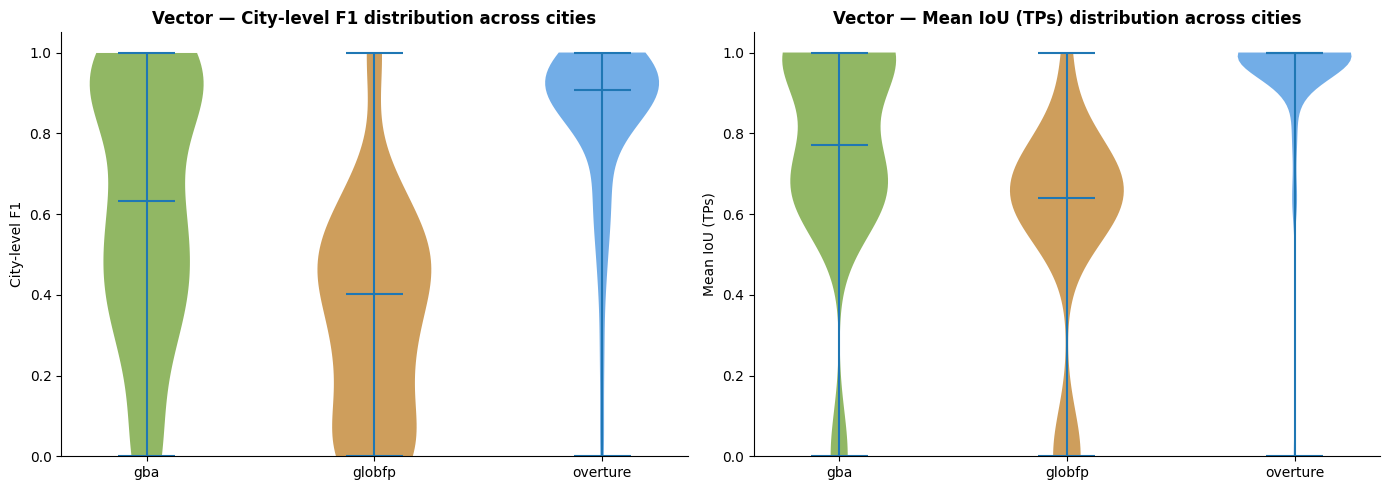

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metric, label) in zip(axes, [
    ("f1_city",    "City-level F1"),
    ("iou_mean_tp", "Mean IoU (TPs)"),
]):
    datasets_order = sorted(df_vec["dataset"].unique())
    data = [df_vec[df_vec["dataset"] == ds][metric].dropna().values for ds in datasets_order]
    parts = ax.violinplot(data, positions=range(len(datasets_order)), showmedians=True)
    for i, (pc, ds) in enumerate(zip(parts["bodies"], datasets_order)):
        pc.set_facecolor(VEC_PALETTE.get(ds, "#aaaaaa"))
        pc.set_alpha(0.7)
    ax.set_xticks(range(len(datasets_order)))
    ax.set_xticklabels(datasets_order)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(label)
    ax.set_title(f"Vector — {label} distribution across cities", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 11. Raster — tile F1 distribution across cities (violin)

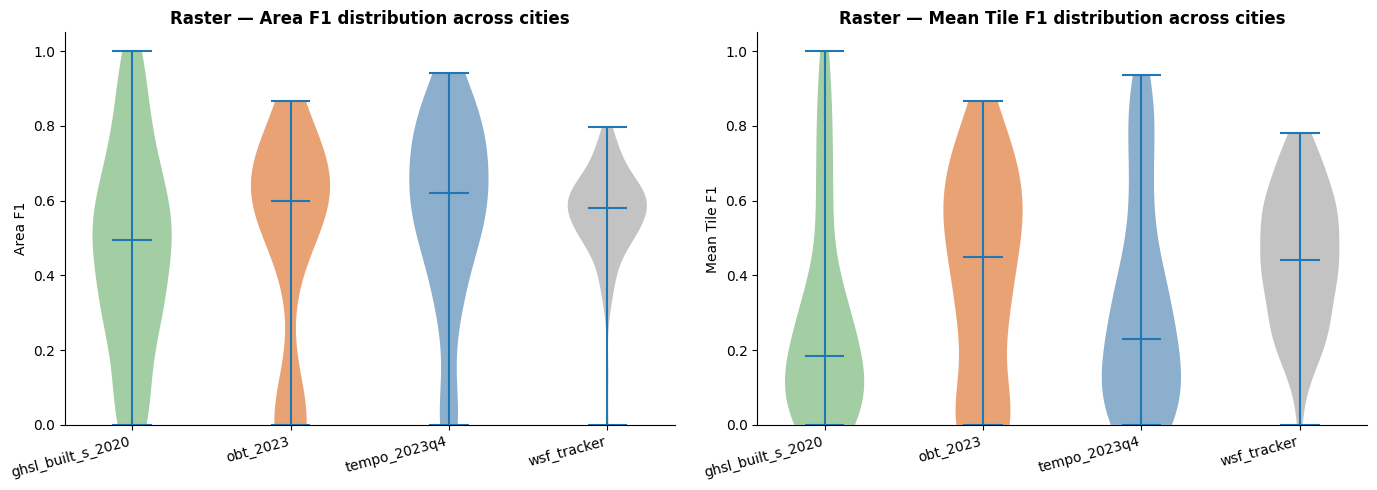

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metric, label) in zip(axes, [
    ("f1_area",     "Area F1"),
    ("tile_f1_mean", "Mean Tile F1"),
]):
    datasets_order = sorted(df_ras["dataset"].unique())
    data = [df_ras[df_ras["dataset"] == ds][metric].dropna().values for ds in datasets_order]
    parts = ax.violinplot(data, positions=range(len(datasets_order)), showmedians=True)
    for i, (pc, ds) in enumerate(zip(parts["bodies"], datasets_order)):
        pc.set_facecolor(RAS_PALETTE.get(ds, "#aaaaaa"))
        pc.set_alpha(0.7)
    ax.set_xticks(range(len(datasets_order)))
    ax.set_xticklabels(datasets_order, rotation=15, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(label)
    ax.set_title(f"Raster — {label} distribution across cities", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()